<a href="https://colab.research.google.com/github/b-li111/knn/blob/main/computer_vision_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Computer Vision

Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and $k$NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)

2. x_train's shape is (6000, 28, 28)-- so 60k training images, with each being 28 x 28 pixels.
x test's shape is (10000, 28, 28) so 10k test images, 28x28 pixels. For each index i it'd just be a 2d image-- 28x28 pixels.
y train's shape is (60000,), so one label for every training image
and y test shape is (10000,)


A single image like X_train[i] or X_test[i] has shape (28, 28) — just one 2D image.

y_train has shape (60000,), which is one label for each training image.

y_test has shape (10000,), one label per test image.



4. I chose 3-- I tried 5 4 and 2, and 3 gave me the highest accuracy.

5 and 6. with k = 3, the accuracy was 97.05%. So a little over 97% of the digits in the test set were correctly predicted, which seems very high, especially for handwritten digits.
For the confusion matrix, the predictions were mostly correct, since the diagonal (aka correct) area had the highest values. In terms of mistakes, it seemed like 5 was sometimes predicted as 6 or 3, 2 and 7 were occasionally confused, and 4 was sometimes predicted as 9. Since these are handwritten, people may be rushed, sloppy, or the numbers just look similar. Overall it seems like the model did really well. And also, the ones confused were the numbers that could be written similarly, which makes sense.



7. ok, you could make the matrix (height, width, 3). The 3 would be for the 3 primary colors-- red, green, blue. Every pixel would have 3 values between 0 and 255 for each color (how colors are determined by a computer). Like pure red would be [255,0,0]. Almost every color has a mixture of all 3. Then you could .reshape() it into one dimension. so multiply it all together to make one vector. For example if it was 1x1 pixels (1, 1, 3) would be multiplied into (3,). Then the data is ready to be put into rows and processed.


In [11]:
from keras.datasets import mnist
import numpy as np


(x_train, y_train), (x_test, y_test) = mnist.load_data()


print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("x_train[0] shape:", x_train[0].shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)
x_train[0] shape: (28, 28)
y_train shape: (60000,)
y_test shape: (10000,)


Label: 7


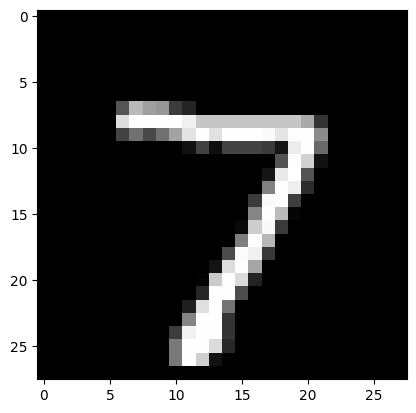

Label: 2


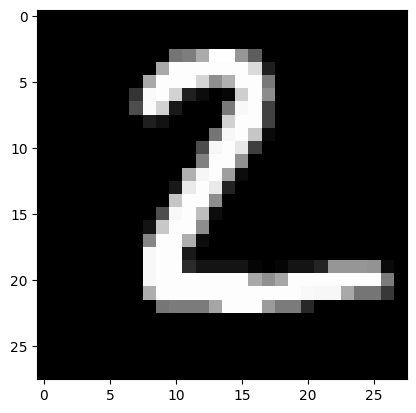

Label: 1


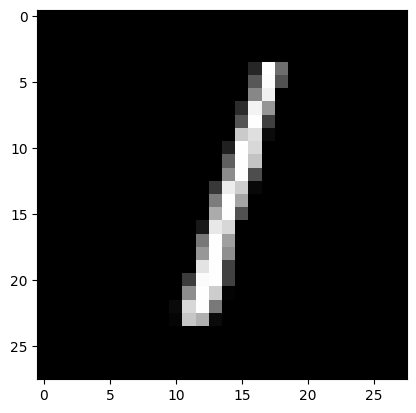

Label: 0


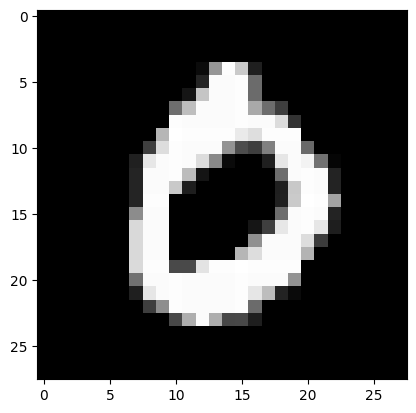

Label: 4


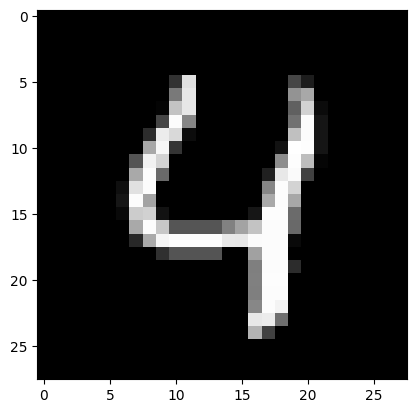

In [4]:
import matplotlib.pyplot as plt

for i in range(5):
    print("Label:", y_test[i])
    plt.imshow(x_test[i], cmap='gray')
    plt.show()


In [5]:
x_train_flat = x_train.reshape((x_train.shape[0], 784))
x_test_flat = x_test.reshape((x_test.shape[0], 784))

print("Flattened X_train shape:", x_train_flat.shape)
print("Flattened X_test shape:", x_test_flat.shape)


Flattened X_train shape: (60000, 784)
Flattened X_test shape: (10000, 784)


In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train_flat, y_train)

y_pred = knn.predict(x_test_flat)

accuracy = accuracy_score(y_test, y_pred)
print("accuracy:", accuracy)


accuracy: 0.9705


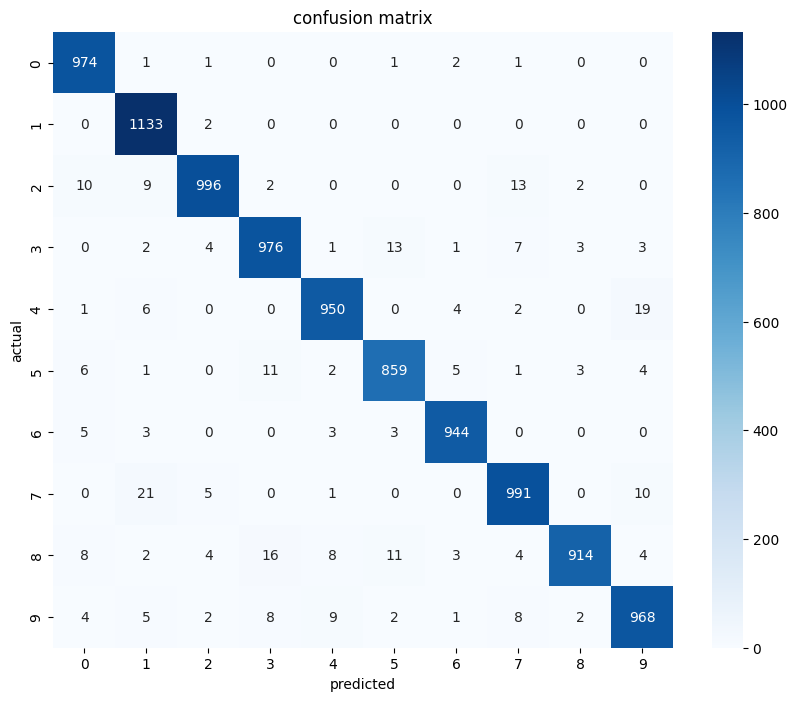

In [10]:
from sklearn.metrics import confusion_matrix

confus_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(confus_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix")
plt.show()
